### Autor: David Roca Tauste
---

## PASO 1: Carga y exploración del JSON

In [1]:
import json5

# Cargar el archivo JSON usando la biblioteca json.
with open("facedetails.json5", "r") as archivo:
    info = json5.load(archivo)

# Identificar las claves principales y sus subniveles (FaceDetails, Emotions, Landmarks, etc.).
print("Mostrar claves principales:")
print(info.keys())

face_details = info.get("FaceDetails", [])

if face_details:
    print("\nClaves de \"FaceDetails\":")
    print(face_details[0].keys())

    subniveles = list(face_details[0].keys())
    print(f"Subniveles de FaceDetails: {subniveles}")

Mostrar claves principales:
dict_keys(['FaceDetails', 'ResponseMetadata'])

Claves de "FaceDetails":
dict_keys(['BoundingBox', 'AgeRange', 'Smile', 'Eyeglasses', 'Sunglasses', 'Gender', 'Beard', 'Mustache', 'EyesOpen', 'MouthOpen', 'Emotions', 'Landmarks', 'Pose', 'Quality', 'Confidence', 'FaceOccluded', 'EyeDirection'])
Subniveles de FaceDetails: ['BoundingBox', 'AgeRange', 'Smile', 'Eyeglasses', 'Sunglasses', 'Gender', 'Beard', 'Mustache', 'EyesOpen', 'MouthOpen', 'Emotions', 'Landmarks', 'Pose', 'Quality', 'Confidence', 'FaceOccluded', 'EyeDirection']


---
## PASO 2: Extracción y muestra de información básica

In [2]:
if face_details:
    cara = face_details[0]  # Coger la primera cara detectada

    # Buscar y mostrar la edad estimada (rango bajo y alto).
    rango_edad = cara.get("AgeRange", {})
    print(f"Rango de edad:")
    print(f"{rango_edad.get('Low')} - {rango_edad.get('High')}")

    # Mostrar si la persona lleva gafas y/o gafas de sol (y la confianza asociada).
    gafas = cara.get("Eyeglasses", {})
    gafas_sol = cara.get("Sunglasses", {})
    print(f"\nGafas: {gafas.get('Value')} (Confianza: {gafas.get('Confidence')}%)")
    print(f"\nGafas de sol: {gafas_sol.get('Value')} (Confianza: {gafas_sol.get('Confidence'):.2f}%)")

    # Determinar el género detectado y su confianza.
    genero = cara.get("Gender", {})
    print(f"\nGénero: {genero.get('Value')} (Confianza: {genero.get('Confidence')}%)")


Rango de edad:
18 - 26

Gafas: True (Confianza: 99.99996948242188%)

Gafas de sol: True (Confianza: 93.65%)

Género: Female (Confianza: 99.85968780517578%)


---
## PASO 3: Análisis de Emociones

Emoción con más confianza: SAD (Confianza: 65.56403350830078%)
Emoción con menos confianza: HAPPY (Confianza: 2.2830512523651123%)


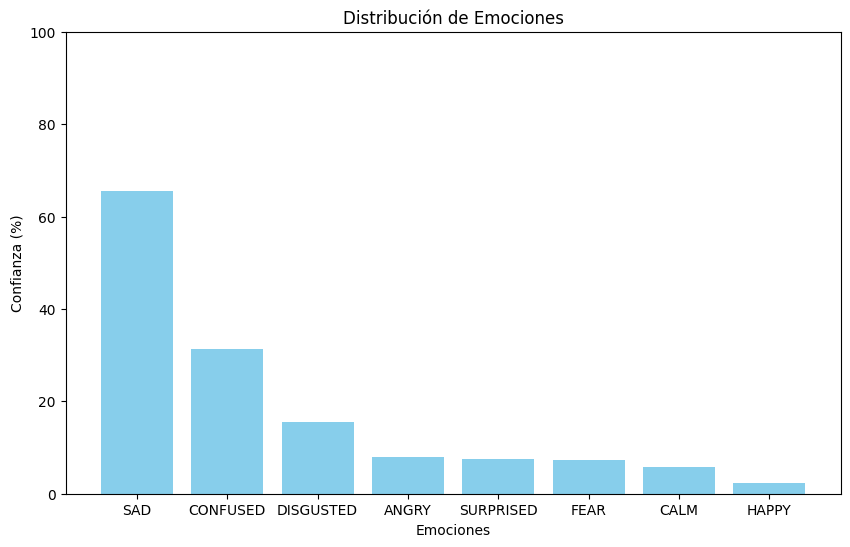

In [3]:
import matplotlib.pyplot as plt

if face_details:
    emotions = cara.get("Emotions", [])

    if emotions:
        # Identificar la emoción con el nivel de confianza más alto, y la de nivel más bajo.
        maxima_emocion = max(emotions, key=lambda e: e["Confidence"])
        minima_emocion = min(emotions, key=lambda e: e["Confidence"])
        print(f"Emoción con más confianza: {maxima_emocion['Type']} (Confianza: {maxima_emocion['Confidence']}%)")
        print(f"Emoción con menos confianza: {minima_emocion['Type']} (Confianza: {minima_emocion['Confidence']}%)")

        # Calcular y mostrar un gráfico de barras con la distribución de emociones.
        tipos_emocion = [e["Type"] for e in emotions]
        confianzas = [e["Confidence"] for e in emotions]

        plt.figure(figsize=(10, 6))
        plt.bar(tipos_emocion, confianzas, color="skyblue")
        plt.xlabel("Emociones")
        plt.ylabel("Confianza (%)")
        plt.title("Distribución de Emociones")
        plt.ylim(0, 100)
        plt.show()


---
## PASO 4: Procesamiento de Puntos de Referencia (Landmarks)

In [4]:
if face_details:
    cara = face_details[0]  # Tomar la primera cara detectada

    # Extraer Landmarks (puntos de la cara)
    landmarks = cara.get("Landmarks", [])
    if landmarks:

        # Extraer las coordenadas de los puntos clave de la cara.
        x_coords = [landmark["X"] for landmark in landmarks]
        y_coords = [landmark["Y"] for landmark in landmarks]
        # tipos_landmark = [landmark["Type"] for landmark in landmarks] (No es necesario)

        print("Puntos clave de la cara extraídos:")
        for i, landmark in enumerate(landmarks):
            print(f"{landmark['Type']}: (X: {landmark['X']}, Y: {landmark['Y']})")


Puntos clave de la cara extraídos:
eyeLeft: (X: 0.30225440859794617, Y: 0.41018882393836975)
eyeRight: (X: 0.6439348459243774, Y: 0.40341562032699585)
mouthLeft: (X: 0.343580037355423, Y: 0.6951127648353577)
mouthRight: (X: 0.6306480765342712, Y: 0.6898072361946106)
nose: (X: 0.47164231538772583, Y: 0.5763645172119141)
leftEyeBrowLeft: (X: 0.1732882857322693, Y: 0.34452149271965027)
leftEyeBrowRight: (X: 0.3655243515968323, Y: 0.33231860399246216)
leftEyeBrowUp: (X: 0.2671719491481781, Y: 0.31669262051582336)
rightEyeBrowLeft: (X: 0.5613729953765869, Y: 0.32813435792922974)
rightEyeBrowRight: (X: 0.7665090560913086, Y: 0.3318614959716797)
rightEyeBrowUp: (X: 0.6612788438796997, Y: 0.3082450032234192)
leftEyeLeft: (X: 0.2416982799768448, Y: 0.4085965156555176)
leftEyeRight: (X: 0.36943578720092773, Y: 0.41230902075767517)
leftEyeUp: (X: 0.29974061250686646, Y: 0.3971870541572571)
leftEyeDown: (X: 0.30360740423202515, Y: 0.42347756028175354)
rightEyeLeft: (X: 0.5755768418312073, Y: 0.408

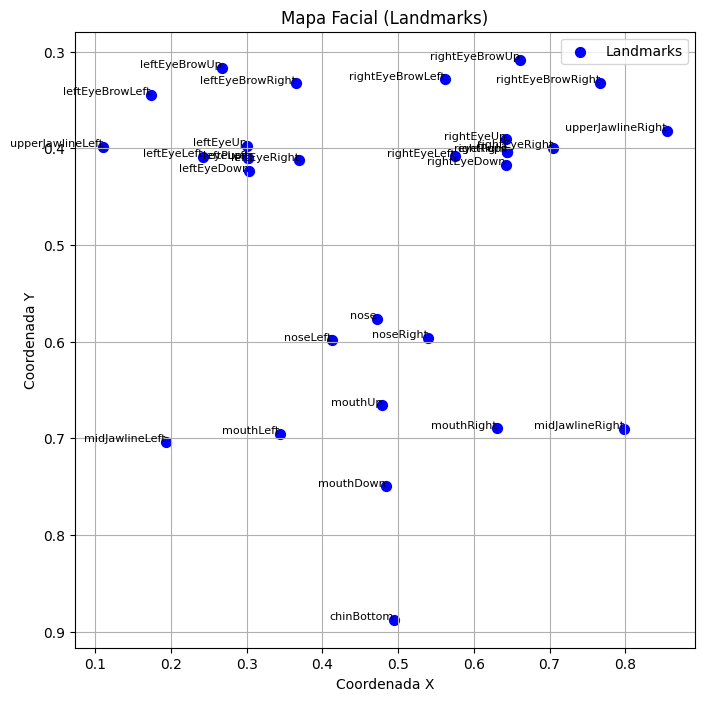

In [5]:
import matplotlib.pyplot as plt

if landmarks:
    # Visualizar estos puntos en una gráfica de dispersión, simulando un mapa facial.
    plt.figure(figsize=(8, 8))
    
    # Graficar puntos
    plt.scatter(x_coords, y_coords, color="blue", s=50, label="Landmarks")
    
    # Añadir etiquetas a los puntos
    for i, landmark in enumerate(landmarks):
        plt.text(x_coords[i], y_coords[i], landmark["Type"], fontsize=8, ha="right")
    
    # Configurar el gráfico
    plt.title("Mapa Facial (Landmarks)")
    plt.xlabel("Coordenada X")
    plt.ylabel("Coordenada Y")
    plt.gca().invert_yaxis()  # Invertir eje Y para alinearse con coordenadas de imagen
    plt.legend()
    plt.grid(True)
    plt.show()
